In [1]:
import numpy as np
import matplotlib.pyplot as plt
def H_matrix(N, t1, t2, y1, y2):
    H_matrix = np.zeros((2*N, 2*N), dtype=complex)
    for i in range(2*N):
        if i == 0:
            H_matrix[i,i], H_matrix[i,i+1],H_matrix[i,2*N-1] = y1 + 1j*y2, t1,t2
        elif i == 2*N-1:
            H_matrix[i,0],H_matrix[i,i-1], H_matrix[i,i] = t2,t1, y1 - 1j*y2
        elif i % 2 == 1:  # 奇数
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t1, y1 - 1j*y2, t2
        else:  # 偶数
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t2, y1 + 1j*y2, t1
    return H_matrix

In [2]:
import numpy as np
import matplotlib.pyplot as plt
def H_matrix(N, t1, t2, y1, y2):
    H_matrix = np.zeros((2*N, 2*N), dtype=complex)
    for i in range(2*N):
        if i == 0:
            H_matrix[i,i], H_matrix[i,i+1] = y1 + 1j*y2, t1
        elif i == 2*N-1:
            H_matrix[i,i-1], H_matrix[i,i] = t1, y1 - 1j*y2
        elif i % 2 == 1:  # 奇数
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t1, y1 - 1j*y2, t2
        else:  # 偶数
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t2, y1 + 1j*y2, t1
    return H_matrix

In [3]:
t1 = 1                         #结果
t2 = 100
y1 = 2
y2 = 2
N=100
H_matrix=H_matrix(N, t1, t2, y1, y2)
Proper_value=np.linalg.eig(H_matrix)[0]
eigenstate=np.linalg.eig(H_matrix)[1]
print(H_matrix)

[[  2.+2.j   1.+0.j   0.+0.j ...   0.+0.j   0.+0.j   0.+0.j]
 [  1.+0.j   2.-2.j 100.+0.j ...   0.+0.j   0.+0.j   0.+0.j]
 [  0.+0.j 100.+0.j   2.+2.j ...   0.+0.j   0.+0.j   0.+0.j]
 ...
 [  0.+0.j   0.+0.j   0.+0.j ...   2.-2.j 100.+0.j   0.+0.j]
 [  0.+0.j   0.+0.j   0.+0.j ... 100.+0.j   2.+2.j   1.+0.j]
 [  0.+0.j   0.+0.j   0.+0.j ...   0.+0.j   1.+0.j   2.-2.j]]


In [4]:
print(len(Proper_value),Proper_value.shape)
print(len(eigenstate),eigenstate.shape)                  #200*1表示一个态

200 (200,)
200 (200, 200)


In [22]:
print(Proper_value)

[  2.        +2.00000000e+00j 101.82851621+1.71032311e-16j
 101.85966685-4.92277991e-16j 101.89093141-2.35950240e-15j
 101.92227894-3.47496679e-15j 101.95367844-2.25160237e-14j
 101.79751034-5.08714411e-14j 102.01650926-2.90444004e-14j
 102.0478786 -1.15437782e-14j 102.07917599-1.77705812e-16j
 101.67554739-2.49264140e-14j 101.70566821+1.52575693e-14j
 -97.92227894-5.79981819e-15j -97.89093141+3.05839531e-15j
 -97.85966685+6.61777673e-16j -97.82851621+7.12137064e-15j
 -97.95367844-4.70609058e-15j -98.0478786 -8.30077500e-15j
 -98.01650926+9.56266279e-15j -97.79751034+1.57477480e-14j
 -98.07917599-1.75176921e-14j -97.64572335+8.83619515e-15j
 -97.67554739+1.38864908e-14j -97.70566821+1.75396505e-14j
 -97.73605583-1.78950832e-14j -98.11037063+2.74452637e-14j
 102.11037063+1.03808218e-14j 101.73605583-7.47320570e-15j
 101.64572335-4.38153697e-15j 101.6162258 +1.47235512e-14j
 -97.6162258 -1.05925642e-14j -96.98029454+3.06924295e-15j
 100.98029454+2.10299443e-14j 102.14143185-1.68684198e-1

Text(0.05, 0.95, 'Total eigenvalues: 200\nMax Im: 2.00\nMin Im: -2.00')

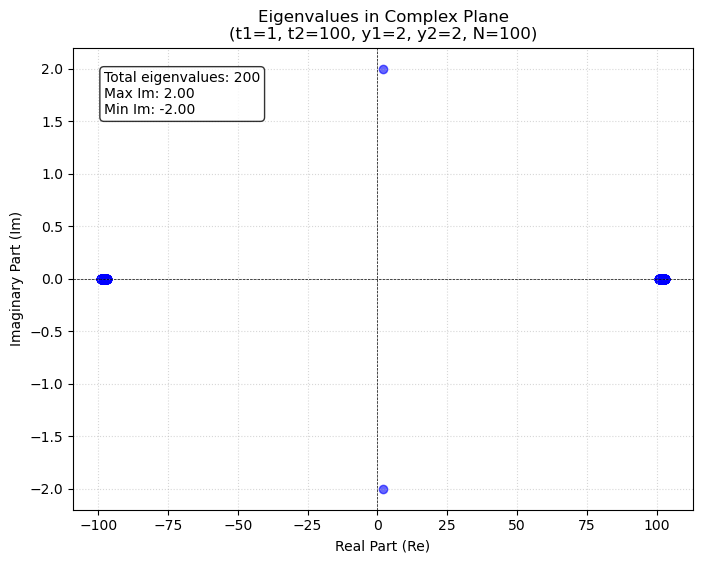

In [23]:
# 提取实部和虚部
real_part = np.real(Proper_value)
imag_part = np.imag(Proper_value)

# 绘制复平面上的特征值分布
plt.figure(figsize=(8, 6))
#plt.xlim(0,4)
plt.scatter(real_part, imag_part, c='b', marker='o', alpha=0.6)
plt.axhline(0, color='k', linestyle='--', linewidth=0.5)  # 实轴
plt.axvline(0, color='k', linestyle='--', linewidth=0.5)  # 虚轴
plt.xlabel('Real Part (Re)')
plt.ylabel('Imaginary Part (Im)')
plt.title('Eigenvalues in Complex Plane\n(t1={}, t2={}, y1={}, y2={}, N={})'.format(t1, t2, y1, y2, N))
plt.grid(True, linestyle=':', alpha=0.5)

# 标记一些统计信息
plt.text(0.05, 0.95, 
         'Total eigenvalues: {}\nMax Im: {:.2f}\nMin Im: {:.2f}'.format(
             len(Proper_value), max(imag_part), min(imag_part)),
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

In [ ]:
"ndarray.ndim	获取ndarray的维数 ndarray.shape	获取ndarray各个维度的长度 ndarray.dtype	获取ndarray中元素的数据类型"
"ndarray.T	简单转置矩阵ndarray"

In [17]:
distribution=np.abs(eigenstate)**2
print(len(distribution[:,0]))
print(prob_dict)

200
{(1.999999999999996+1.936369208312885j): array([7.30608523e-05, 2.95814452e-07, 1.64179072e-04, 1.18213566e-06,
       2.91274222e-04, 2.65560145e-06, 4.53864179e-04, 4.71062234e-06,
       6.51332172e-04, 7.33940281e-06, 8.82929123e-04, 1.05319708e-05,
       1.14777649e-03, 1.42762156e-05, 1.44486960e-03, 1.85579337e-05,
       1.77308145e-03, 2.33608828e-05, 2.13116699e-03, 2.86668433e-05,
       2.51776788e-03, 3.44556875e-05, 2.93141756e-03, 4.07054560e-05,
       3.37054689e-03, 4.73924408e-05, 3.83349007e-03, 5.44912754e-05,
       4.31849098e-03, 6.19750310e-05, 4.82370979e-03, 6.98153186e-05,
       5.34723002e-03, 7.79823968e-05, 5.88706572e-03, 8.64452845e-05,
       6.44116908e-03, 9.51718784e-05, 7.00743815e-03, 1.04129075e-04,
       7.58372485e-03, 1.13282896e-04, 8.16784308e-03, 1.22598617e-04,
       8.75757703e-03, 1.32040899e-04, 9.35068961e-03, 1.41573925e-04,
       9.94493089e-03, 1.51161532e-04, 1.05380467e-02, 1.60767349e-04,
       1.11277870e-02, 1.7035493

In [15]:
import numpy as np

eigen_dict = {Proper_value[i]: eigenstate[:, i] for i in range(len(Proper_value))}

distribution = np.abs(eigenstate)**2
prob_dict = {Proper_value[i]: distribution[:, i] for i in range(len(Proper_value))}


In [18]:
import os
import matplotlib.pyplot as plt
import numpy as np

# 创建保存目录
base_dir = r"C:\Users\taoji\Desktop\结果\本征值和本征态"
real_dir = os.path.join(base_dir, "实部")
imag_dir = os.path.join(base_dir, "虚部")
os.makedirs(real_dir, exist_ok=True)
os.makedirs(imag_dir, exist_ok=True)

# 定义分类条件
def classify_eigenvalue(eig_val):
    """将特征值分为实部主导或虚部主导"""
    real_part = np.real(eig_val)
    imag_part = np.imag(eig_val)
    
    # 实部主导类：虚部绝对值 < 1e-2
    if np.abs(imag_part) < 1e-2:
        return "real"
    # 虚部主导类：实部接近2（在2±0.02范围内）
    elif np.abs(real_part - 2) < 1e-2:
        return "imag"
    else:
        return None

# 分类并绘图
for eig_val, prob_dist in prob_dict.items():
    cls = classify_eigenvalue(eig_val)
    
    if cls == "real":
        save_dir = real_dir
        title = f"实部主导 (E={np.real(eig_val):.4f})"
        filename = f"0_real_E_{np.real(eig_val):.6f}.png"
    elif cls == "imag":
        save_dir = imag_dir
        title = f"虚部主导 (E={np.imag(eig_val):.4f}i)"
        filename = f"1_imag_E_{np.imag(eig_val):.6f}i.png"
    else:
        continue
    
    # 创建图形
    plt.figure(figsize=(10, 5))
    plt.plot(range(2*N), prob_dist, 'b-', linewidth=1)
    plt.xlabel("格点位置n")
    plt.ylabel("概率幅|ψ|²")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    
    # 保存图形
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    
print(f"实部主导的图已保存到: {real_dir}")
print(f"虚部主导的图已保存到: {imag_dir}")

C:\Users\taoji\AppData\Local\Temp\ipykernel_12456\989931976.py:52: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
C:\Users\taoji\AppData\Local\Temp\ipykernel_12456\989931976.py:52: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
C:\Users\taoji\AppData\Local\Temp\ipykernel_12456\989931976.py:52: UserWarning: Glyph 24133 (\N{CJK UNIFIED IDEOGRAPH-5E45}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
C:\Users\taoji\AppData\Local\Temp\ipykernel_12456\989931976.py:52: UserWarning: Glyph 34394 (\N{CJK UNIFIED IDEOGRAPH-865A}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
C:\Users\taoji\AppData\Local\Temp\ipykernel_12456\989931976.py:52: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from current font.
  plt.savefig(save_p

实部主导的图已保存到: C:\Users\taoji\Desktop\结果\本征值和本征态\实部_1
虚部主导的图已保存到: C:\Users\taoji\Desktop\结果\本征值和本征态\虚部_1


动态图已保存为: C:\Users\taoji\Desktop\结果\本征值和本征态\虚部_t2=0.5\imaginary_part_animation.gif


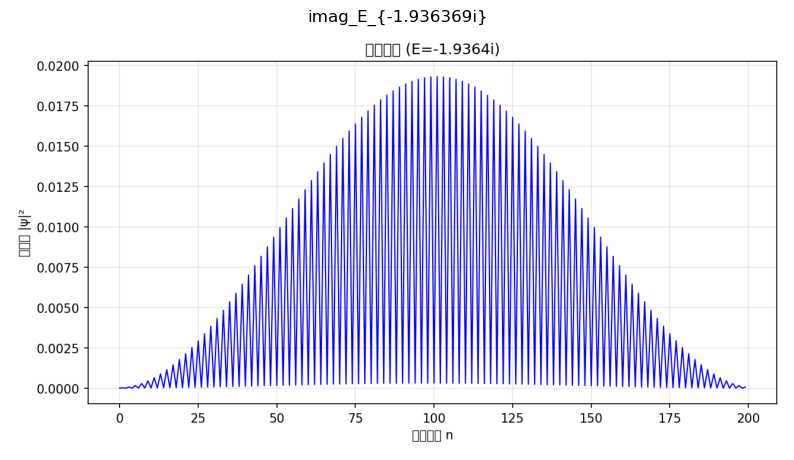

In [21]:
import os
import re
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from PIL import Image
from natsort import natsorted

# 设置文件夹路径
folder_path = r"C:\Users\taoji\Desktop\结果\本征值和本征态\虚部_t2=0.5"

# 获取所有符合条件的图像文件
image_files = [f for f in os.listdir(folder_path) if f.startswith("imag_E_") and f.endswith(".png")]

# 使用自然排序对文件名进行排序
image_files = natsorted(image_files)

# 创建一个正则表达式来提取虚部数值
pattern = re.compile(r"imag_E_(-?\d+\.\d+)i\.png")

# 创建一个图形窗口
fig = plt.figure(figsize=(10, 8))
plt.axis('off')

# 预加载所有图像
images = []
titles = []

for img_file in image_files:
    # 提取虚部数值
    match = pattern.match(img_file)
    if match:
        imag_value = match.group(1)
        title = f"imag_E_{{{imag_value}i}}"
        titles.append(title)
        
        # 加载图像
        img_path = os.path.join(folder_path, img_file)
        img = Image.open(img_path)
        images.append(img)

# 创建动画函数
def update(frame):
    plt.clf()
    plt.axis('off')
    plt.imshow(images[frame])
    plt.title(titles[frame], fontsize=12, pad=10)
    return []

# 创建动画
ani = animation.FuncAnimation(
    fig, 
    update, 
    frames=len(images),
    interval=200,  # 每帧间隔200毫秒
    blit=True,
    repeat=True
)

# 保存为GIF
output_gif = os.path.join(folder_path, "imaginary_part_animation.gif")
ani.save(output_gif, writer='pillow', fps=5, dpi=100)

print(f"动态图已保存为: {output_gif}")

# 显示动画 (可选)
plt.show()

In [20]:
pip install natsort

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

def H_matrix(N, t1, t2, y1, y2):
    """
    构建开放边界条件下的哈密顿矩阵
    参数:
        N: 晶格单元数
        t1, t2: 跃迁强度
        y1, y2: 在位能实部和虚部
    返回:
        2N×2N的复数哈密顿矩阵
    """
    H_matrix = np.zeros((2*N, 2*N), dtype=complex)
    for i in range(2*N):
        if i == 0:  # 第一个格点
            H_matrix[i,i], H_matrix[i,i+1] = y1 + 1j*y2, t1
        elif i == 2*N-1:  # 最后一个格点
            H_matrix[i,i-1], H_matrix[i,i] = t1, y1 - 1j*y2
        elif i % 2 == 1:  # 奇数格点
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t1, y1 - 1j*y2, t2
        else:  # 偶数格点
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t2, y1 + 1j*y2, t1
    return H_matrix

# 物理参数设置
t1 = 1    # 奇数格点间跃迁
t2 =  4     # 偶数格点间跃迁
y1 = 0    # 在位能实部
y2 = 0    # 在位能虚部
N = 100   # 晶格单元数

# 计算哈密顿矩阵
H = H_matrix(N, t1, t2, y1, y2)

# 计算本征值和本征态
Proper_value = np.linalg.eig(H)[0]  # 本征值
eigenstate = np.linalg.eig(H)[1]    # 本征态

# 提取实部和虚部
real_part = np.real(Proper_value)
imag_part = np.imag(Proper_value)

# 创建结果保存目录
base_dir = r"C:\Users\taoji\Desktop\结果\本征值和本征态"
param_dir = os.path.join(base_dir, f"t1_{t1}_t2_{t2}_y1_{y1}_y2_{y2}_N_{N}")
os.makedirs(param_dir, exist_ok=True)  # 自动创建目录

# 创建实部主导和虚部主导的子目录
real_dir = os.path.join(param_dir, "实部主导")
imag_dir = os.path.join(param_dir, "虚部主导")
os.makedirs(real_dir, exist_ok=True)
os.makedirs(imag_dir, exist_ok=True)

def classify_eigenvalue(eig_val):
    """
    分类本征值为实部主导或虚部主导
    参数:
        eig_val: 复数本征值
    返回:
        "real": 实部主导
        "imag": 虚部主导
    """
    imag_part = np.imag(eig_val)
    if np.abs(imag_part) < 1e-6:  # 虚部小于10^-6视为实部主导
        return "real"
    else:  # 否则视为虚部主导
        return "imag"

# 计算概率分布 |ψ|²
distribution = np.abs(eigenstate) ** 2
prob_dict = {Proper_value[i]: distribution[:, i] for i in range(len(Proper_value))}

# 遍历所有本征态并保存图像
for eig_val, prob_dist in prob_dict.items():
    cls = classify_eigenvalue(eig_val)
    
    if cls == "real":
        save_dir = real_dir
        title = f"实部主导 (E={np.real(eig_val):.10f})"
        filename = f"0_real_E_{np.real(eig_val):.12f}.png"
    else:
        save_dir = imag_dir
        title = f"复数主导 (E={np.imag(eig_val):.10f}i)"
        filename = f"1_imag_E_{np.imag(eig_val):.12f}i.png"
    
    # 绘制本征态概率分布
    plt.figure(figsize=(10, 5))
    plt.plot(range(2 * N), prob_dist, 'b-', linewidth=1)
    plt.xlabel("格点位置 n")
    plt.ylabel("概率幅 |ψ|²")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    
    # 保存图像
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

# 绘制本征值在复平面的分布
plt.figure(figsize=(8, 6))
plt.scatter(real_part, imag_part, c='b', marker='o', alpha=0.6)
plt.axhline(0, color='k', linestyle='--', linewidth=0.5)  # 实轴
plt.axvline(0, color='k', linestyle='--', linewidth=0.5)  # 虚轴
plt.xlabel('实部 (Re)')
plt.ylabel('虚部 (Im)')
plt.title(f'复平面上的本征值分布\n(t1={t1}, t2={t2}, y1={y1}, y2={y2}, N={N})')
plt.grid(True, linestyle=':', alpha=0.5)

# 添加统计信息
plt.text(0.05, 0.95, 
         f'本征值总数: {len(Proper_value)}\n最大虚部: {max(imag_part):.2f}\n最小虚部: {min(imag_part):.2f}',
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 保存本征值分布图
eigenvalue_plot_path = os.path.join(param_dir, f'eigenvalue_scatter_t1_{t1}_t2_{t2}_y1_{y1}_y2_{y2}_N_{N}.png')
plt.savefig(eigenvalue_plot_path, dpi=150, bbox_inches='tight')
plt.close()

print(f"所有结果已保存至: {param_dir}")

C:\Users\taoji\AppData\Local\Temp\ipykernel_7068\4041512838.py:98: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
C:\Users\taoji\AppData\Local\Temp\ipykernel_7068\4041512838.py:98: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
C:\Users\taoji\AppData\Local\Temp\ipykernel_7068\4041512838.py:98: UserWarning: Glyph 24133 (\N{CJK UNIFIED IDEOGRAPH-5E45}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
C:\Users\taoji\AppData\Local\Temp\ipykernel_7068\4041512838.py:98: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
C:\Users\taoji\AppData\Local\Temp\ipykernel_7068\4041512838.py:98: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from current font.
  plt.savefig(save_p

所有结果已保存至: C:\Users\taoji\Desktop\结果\本征值和本征态\t1_1_t2_4_y1_0_y2_0_N_100


In [ ]:
import numpy as np                                 #最终
import matplotlib.pyplot as plt
import os

def H_matrix(N, t1, t2, y1, y2):
    """
    Construct Hamiltonian matrix with open boundary conditions
    Args:
        N: number of unit cells
        t1, t2: hopping amplitudes
        y1, y2: on-site potential (real and imaginary parts)
    Returns:
        2N×2N complex Hamiltonian matrix
    """
    H_matrix = np.zeros((2*N, 2*N), dtype=complex)
    for i in range(2*N):
        if i == 0:  # first site
            H_matrix[i,i], H_matrix[i,i+1] = y1 + 1j*y2, t1
        elif i == 2*N-1:  # last site
            H_matrix[i,i-1], H_matrix[i,i] = t1, y1 - 1j*y2
        elif i % 2 == 1:  # odd site
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t1, y1 - 1j*y2, t2
        else:  # even site
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t2, y1 + 1j*y2, t1
    return H_matrix

# Parameters
t1 = 1    # intra-cell hopping
t2 = 4    # inter-cell hopping
y1 = 0    # real part of on-site potential
y2 = 0    # imaginary part of on-site potential
N = 100   # number of unit cells

# Compute Hamiltonian matrix
H = H_matrix(N, t1, t2, y1, y2)

# Compute eigenvalues and eigenstates
eigenvalues = np.linalg.eig(H)[0]  # eigenvalues
eigenstates = np.linalg.eig(H)[1]  # eigenstates

# Extract real and imaginary parts
real_part = np.real(eigenvalues)
imag_part = np.imag(eigenvalues)

# Create output directories
base_dir = r"C:\Users\taoji\Desktop\结果\本征值和本征态"
param_dir = os.path.join(base_dir, f"t1_{t1}_t2_{t2}_y1_{y1}_y2_{y2}_N_{N}")
os.makedirs(param_dir, exist_ok=True)

# Subdirectories for real and complex dominant eigenvalues
real_dir = os.path.join(param_dir, "real_dominant")
imag_dir = os.path.join(param_dir, "imag_dominant")
os.makedirs(real_dir, exist_ok=True)
os.makedirs(imag_dir, exist_ok=True)

def classify_eigenvalue(eig_val):
    """
    Classify eigenvalue as real-dominant or complex-dominant
    Args:
        eig_val: complex eigenvalue
    Returns:
        "real": real-dominant
        "imag": complex-dominant
    """
    imag_part = np.imag(eig_val)
    if np.abs(imag_part) < 1e-6:  # consider as real if imag < 1e-6
        return "real"
    else:
        return "imag"

# Compute probability distribution |ψ|²
distribution = np.abs(eigenstates) ** 2
prob_dict = {eigenvalues[i]: distribution[:, i] for i in range(len(eigenvalues))}

# Process and plot all eigenstates
for eig_val, prob_dist in prob_dict.items():
    real_val = np.real(eig_val)
    imag_val = np.imag(eig_val)
    
    # Format values for filename (scientific notation)
    real_str = "{:.6e}".format(real_val).replace('+', '').replace('-', 'm')
    imag_str = "{:.6e}".format(imag_val).replace('+', '').replace('-', 'm')
    
    cls = classify_eigenvalue(eig_val)
    
    if cls == "real":
        save_dir = real_dir
        title = f"Real-dominant (Re={real_val:.6f}, Im={imag_val:.6f})"
        filename = f"real_Re_{real_str}_Im_{imag_str}.png"
    else:
        save_dir = imag_dir
        title = f"Complex-dominant (Re={real_val:.6f}, Im={imag_val:.6f})"
        filename = f"complex_Re_{real_str}_Im_{imag_str}.png"
    
    # Plot eigenstate distribution
    plt.figure(figsize=(10, 5))
    plt.plot(range(2 * N), prob_dist, 'b-', linewidth=1)
    plt.xlabel("Site index n")
    plt.ylabel("Probability amplitude |ψ|²")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    
    # Save figure
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

# Plot eigenvalue distribution in complex plane
plt.figure(figsize=(8, 6))
plt.scatter(real_part, imag_part, c='b', marker='o', alpha=0.6)
plt.axhline(0, color='k', linestyle='--', linewidth=0.5)  # real axis
plt.axvline(0, color='k', linestyle='--', linewidth=0.5)  # imaginary axis
plt.xlabel('Real part (Re)')
plt.ylabel('Imaginary part (Im)')
plt.title(f'Eigenvalue spectrum\n(t1={t1}, t2={t2}, y1={y1}, y2={y2}, N={N})')
plt.grid(True, linestyle=':', alpha=0.5)

# Add statistical information
plt.text(0.05, 0.95, 
         f'Total eigenvalues: {len(eigenvalues)}\nMax Im: {max(imag_part):.2f}\nMin Im: {min(imag_part):.2f}',
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Save eigenvalue plot
eigenvalue_plot_path = os.path.join(param_dir, f'eigenvalue_spectrum_t1_{t1}_t2_{t2}_y1_{y1}_y2_{y2}_N_{N}.png')
plt.savefig(eigenvalue_plot_path, dpi=150, bbox_inches='tight')
plt.close()

print(f"All results saved to: {param_dir}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

def H_matrix(N, t1, t2, y1, y2):
    """
    构建一维非厄米链的哈密顿矩阵（开放边界条件）
    
    参数：
        N (int): 晶胞数量（每个晶胞包含2个格点）
        t1 (float): 晶胞内跃迁振幅（奇数位置间的跃迁）
        t2 (float): 晶胞间跃迁振幅（偶数位置间的跃迁） 
        y1 (float): 在位势能的实部
        y2 (float): 在位势能的虚部（非厄米项）
        
    返回：
        np.ndarray: 2N×2N的复数哈密顿矩阵
    """
    H_matrix = np.zeros((2*N, 2*N), dtype=complex)
    for i in range(2*N):
        if i == 0:  # 第一个格点（特殊边界条件）
            H_matrix[i,i], H_matrix[i,i+1] = y1 + 1j*y2, t1
        elif i == 2*N-1:  # 最后一个格点（特殊边界条件）
            H_matrix[i,i-1], H_matrix[i,i] = t1, y1 - 1j*y2
        elif i % 2 == 1:  # 奇数位置格点
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t1, y1 - 1j*y2, t2
        else:  # 偶数位置格点
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t2, y1 + 1j*y2, t1
    return H_matrix

# 物理参数设置
t1 = 1    # 晶胞内跃迁强度（奇数格点间）
t2 = 4    # 晶胞间跃迁强度（偶数格点间）
y1 = 0    # 在位势能实部
y2 = 0    # 在位势能虚部（非厄米项）
N = 100   # 晶胞数量

# 计算哈密顿矩阵
H = H_matrix(N, t1, t2, y1, y2)

# 计算本征值和本征态
eigenvalues = np.linalg.eig(H)[0]  # 本征值
eigenstates = np.linalg.eig(H)[1]  # 本征态

# 提取实部和虚部
real_part = np.real(eigenvalues)
imag_part = np.imag(eigenvalues)

# 创建结果保存目录
base_dir = r"C:\Users\taoji\Desktop\结果\本征值和本征态"
param_dir = os.path.join(base_dir, f"t1_{t1}_t2_{t2}_y1_{y1}_y2_{y2}_N_{N}")
os.makedirs(param_dir, exist_ok=True)  # 自动创建目录

# 创建子目录：实部主导和虚部主导的本征态
real_dir = os.path.join(param_dir, "实部主导")
imag_dir = os.path.join(param_dir, "虚部主导")
os.makedirs(real_dir, exist_ok=True)
os.makedirs(imag_dir, exist_ok=True)

def classify_eigenvalue(eig_val):
    """
    本征值分类函数
    
    参数：
        eig_val (complex): 复数本征值
        
    返回：
        str: "real"表示实部主导，"imag"表示虚部主导
    """
    imag_part = np.imag(eig_val)
    if np.abs(imag_part) < 1e-6:  # 虚部绝对值小于1e-6视为实部主导
        return "real"
    else:
        return "imag"

# 计算概率分布 |ψ|²
distribution = np.abs(eigenstates) ** 2
prob_dict = {eigenvalues[i]: distribution[:, i] for i in range(len(eigenvalues))}

# 遍历所有本征态并保存图像
for eig_val, prob_dist in prob_dict.items():
    real_val = np.real(eig_val)
    imag_val = np.imag(eig_val)
    
    # 格式化文件名中的数值（科学计数法）
    real_str = "{:.6e}".format(real_val).replace('+', '').replace('-', 'm')
    imag_str = "{:.6e}".format(imag_val).replace('+', '').replace('-', 'm')
    
    cls = classify_eigenvalue(eig_val)
    
    if cls == "real":
        save_dir = real_dir
        title = f"实部主导 (Re={real_val:.6f}, Im={imag_val:.6f})"
        filename = f"real_Re_{real_str}_Im_{imag_str}.png"
    else:
        save_dir = imag_dir
        title = f"虚部主导 (Re={real_val:.6f}, Im={imag_val:.6f})"
        filename = f"complex_Re_{real_str}_Im_{imag_str}.png"
    
    # 绘制本征态概率分布图
    plt.figure(figsize=(10, 5))
    plt.plot(range(2 * N), prob_dist, 'b-', linewidth=1)
    plt.xlabel("格点位置 n")
    plt.ylabel("概率幅 |ψ|²")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    
    # 保存图像
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

# 绘制复平面上的本征值分布
plt.figure(figsize=(8, 6))
plt.scatter(real_part, imag_part, c='b', marker='o', alpha=0.6)
plt.axhline(0, color='k', linestyle='--', linewidth=0.5)  # 实轴
plt.axvline(0, color='k', linestyle='--', linewidth=0.5)  # 虚轴
plt.xlabel('实部 (Re)')
plt.ylabel('虚部 (Im)')
plt.title(f'本征值分布\n(t1={t1}, t2={t2}, y1={y1}, y2={y2}, N={N})')
plt.grid(True, linestyle=':', alpha=0.5)

# 添加统计信息
plt.text(0.05, 0.95, 
         f'总本征值数: {len(eigenvalues)}\n最大虚部: {max(imag_part):.2f}\n最小虚部: {min(imag_part):.2f}',
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 保存本征值分布图
eigenvalue_plot_path = os.path.join(param_dir, f'eigenvalue_spectrum_t1_{t1}_t2_{t2}_y1_{y1}_y2_{y2}_N_{N}.png')
plt.savefig(eigenvalue_plot_path, dpi=150, bbox_inches='tight')
plt.close()

print(f"所有结果已保存至: {param_dir}")